<h1> Proxecto Power BI: Análise de Datos de Fútbol<h1>

 Obxectivo

Analizar estatísticas de equipos e xogadores de fútbol, cruzando datos de distintas fontes para obter información valiosa sobre rendemento, condicións meteorolóxicas durante os partidos e outros factores relevantes.

<P>Instalacions de los modulos que nos van a hacer falta<P>

In [ ]:
#%pip install fake-useragent
#%pip install bs4
#%pip install pyspark
#%pip install webdriver_manager
#%pip install selenium

<p>%pip install fake-useragent
Instala la librería fake-useragent, que permite generar cabeceras User-Agent aleatorias para evitar ser bloqueado por páginas web al hacer scraping.<p>

<p>%pip install bs4
Instala BeautifulSoup 4, que se utiliza para parsear y analizar HTML de las páginas web que descargas.<p>

<p>%pip install pyspark
Instala PySpark, la interfaz de Python para Apache Spark, útil si quieres hacer análisis de datos distribuidos a gran escala (no se usa en el código que compartiste, pero puedes usarlo si planeas procesar grandes volúmenes de datos).<p>

<p>%pip install webdriver_manager
Instala webdriver_manager, que facilita la gestión automática de drivers como chromedriver para Selenium (no necesario para tu scraper actual con requests, pero útil si usas Selenium más adelante).<p>

<p>%pip install selenium
Instala Selenium, una herramienta para automatizar navegadores web, ideal para scraping cuando los datos se cargan dinámicamente con JavaScript.<p>

<h1> Scraping Página del Tiempo<h1>


<p> Aquí vamos a scrapear la página de Tiempo.com para obtener los datos meteorológicos actuales y pronósticos de 7 días desde la web Tiempo.com para varias ciudades españolas.<p>
 <p> Para eso vamos a usar requests para hacer solicitudes HTTP y BeautifulSoup para analizar el HTML. <p>
 <p> Después vamos a generar cabeceras aleatorias con fake_useragent para evitar bloqueos. <p> 
 <p> Después de generar las cabeceras, vamos a recorrer un diccionario de ciudades con sus URLs específicas y, para cada una, vamos a hacer una solicitud a la página correspondiente. <p> 
 <p> Después vamos a extraer la temperatura, condición climática y humedad actual, y también los datos de pronóstico diario. <p> 
 <p> Después vamos a almacenar todos los datos y se van a guardar en un diccionario weather_data y luego se combinan en un DataFrame de pandas. <p>
 <p> Finalmente, después de hacer todo esto, vamos a guardar los resultados en archivos CSV y JSON con la fecha actual en el nombre. <p> 
 <p> Después vamos a imprimir un resumen de los registros recolectados, y calculas el tiempo total de ejecución del script. <p>


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json
import time
from datetime import datetime
import random
from fake_useragent import UserAgent

# Configuracion
base_url = "https://www.tiempo.com"
current_date = datetime.now().strftime("%Y-%m-%d")
user_agent = UserAgent()

# Diccionario ampliado de ciudades con URLs corregidas
cities = {
    "Madrid": "/madrid.htm",
    "Barcelona": "/barcelona.htm",
    "Valencia": "/valencia.htm",
    "Sevilla": "/sevilla.htm",
    "Zaragoza": "/zaragoza.htm",
    "Málaga": "/malaga.htm",
    "Murcia": "/murcia.htm",
    "Palma": "/palma-de-mallorca.htm",
    "Las Palmas": "/las-palmas-de-gran-canaria.htm",
    "Bilbao": "/bilbao.htm",
    "Alicante": "/alicante-alacant.htm",  
    "Córdoba": "/cordoba.htm",
    "Valladolid": "/valladolid.htm",
    "Vigo": "/vigo.htm",
    "Gijón": "/gijon.htm",
    "Hospitalet de Llobregat": "/gn/3120619.htm",
    "A Coruña": "/coruna-a.htm",  
    "Vitoria-Gasteiz": "/vitoria-gasteiz.htm",
    "Granada": "/granada.htm",
    "Elche": "/elche-elx.htm",
    "Oviedo": "/oviedo.htm",
    "Santa Cruz de Tenerife": "/santa-cruz-de-tenerife.htm",
    "Badalona": "/badalona.htm",
    "Cartagena": "/cartagena.htm",
    "Terrassa": "/terrassa.htm",
    "Jerez de la Frontera": "/jerez-de-la-frontera.htm",
    "Sabadell": "/sabadell.htm",
    "Móstoles": "/mostoles.htm",
    "Alcalá de Henares": "/alcala-de-henares.htm",
    "Pamplona": "/pamplona.htm"
}

# Headers dinamicos
def get_headers():
    return {
        'User-Agent': user_agent.random,
        'Accept-Language': 'es-ES,es;q=0.9',
        'Referer': 'https://www.google.com/',
        'Accept-Encoding': 'gzip, deflate, br'
    }

# Almacenamiento de datos
weather_data = {
    'actual': [],
    'futuro': []
}

def get_weather_data():
    """Función principal para obtener todos los datos meteorológicos"""
    print("=== Iniciando recolección de datos meteorológicos ===")
    
    for city_name, city_path in cities.items():
        print(f"\nProcesando ciudad: {city_name}")
        time.sleep(random.uniform(1, 3))  # Reduce el tiempo de espera entre solicitudes
        
        try:
            url = f"{base_url}{city_path}"
            response = requests.get(url, headers=get_headers())
            response.raise_for_status()
            soup = BeautifulSoup(response.text, 'html.parser')
            
            extract_current_data(soup, city_name)
            extract_forecast_data(soup, city_name)
        
        except Exception as e:
            print(f"Error procesando {city_name}: {str(e)}")
            continue

def extract_current_data(soup, city_name):
    try:
        current = {
            'ciudad': city_name,
            'tipo': 'actual',
            'fecha': current_date,
            'timestamp': datetime.now().isoformat()
        }
        
        temp = soup.select_one('.dato-temperatura.changeUnitT')
        if temp:
            current['temperatura'] = temp.get_text(strip=True)
        
        condition = soup.select_one('.descripcion')
        if condition:
            current['condicion'] = condition.get_text(strip=True)
        
        humidity = soup.select_one('.datos-humedad')
        if humidity:
            current['humedad'] = humidity.get_text(strip=True)
        
        weather_data['actual'].append(current)
        print(f"Datos actuales obtenidos para {city_name}")
        
    except Exception as e:
        print(f"Error extrayendo datos actuales: {str(e)}")

def extract_forecast_data(soup, city_name):
    try:
        forecast_table = soup.select_one('.grid-container-7')
        if not forecast_table:
            print("No se encontró tabla de pronóstico")
            return
            
        rows = forecast_table.select('li')  # Los días están en <li> en lugar de <tr>
        
        for i, row in enumerate(rows[:7]):  # Limitar a los primeros 7 días
            date_element = row.select_one('.fecha')
            temp_element = row.select_one('.temperatura')
            condition_element = row.select_one('.descripcion')
            
            if all([date_element, temp_element, condition_element]):
                forecast = {
                    'ciudad': city_name,
                    'tipo': 'pronostico',
                    'fecha': date_element.get_text(strip=True),
                    'temperatura': temp_element.get_text(strip=True),
                    'condicion': condition_element.get_text(strip=True),
                    'timestamp': datetime.now().isoformat()
                }
                weather_data['futuro'].append(forecast)
        
        print(f"Pronóstico futuro obtenido para {city_name} (7 días)")
        
    except Exception as e:
        print(f"Error extrayendo pronóstico futuro: {str(e)}")

def save_data():
    try:
        all_data = weather_data['actual'] + weather_data['futuro']
        df = pd.DataFrame(all_data)
        df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
        df.sort_values(by=['ciudad', 'fecha'], inplace=True)
        
        csv_file = f"datos_tiempo_completos_{current_date}.csv"
        df.to_csv(csv_file, index=False, encoding='utf-8-sig')
        
        json_file = f"datos_tiempo_completos_{current_date}.json"
        with open(json_file, 'w', encoding='utf-8') as f:
            json.dump(all_data, f, ensure_ascii=False, indent=2)
        
        print(f"\n Datos guardados en {csv_file} y {json_file}")
        print("\nResumen de datos recolectados:")
        print(f"- Actuales: {len(weather_data['actual'])} registros")
        print(f"- Futuros: {len(weather_data['futuro'])} registros")
        
        return df
        
    except Exception as e:
        print(f"Error guardando datos: {str(e)}")
        return None

if __name__ == "__main__":
    start_time = time.time()
    
    get_weather_data()
    weather_df = save_data()
    
    end_time = time.time()
    print(f"\nTiempo total de ejecución: {round(end_time - start_time, 2)} segundos")
    
    if weather_df is not None:
        print("\nPrimeras filas del DataFrame:")
        print(weather_df.head())


<h1> Scraping Página de Futbol<h1>


<p> Para hacer el scraping vamos a usar Selenium para automatizar la extracción de datos de partidos de LaLiga desde la web de Flashscore. <p>
<p> Para eso vamos a configurar el navegador Chrome con opciones para tamaño y notificaciones, y opcionalmente modo headless. <p>
<p> Después de cargar la página, aceptas cookies si aparece el aviso, haces scroll para cargar más contenido y esperas a que los elementos de partidos estén presentes. <p>
<p> Después vamos a extraer la hora, equipo local y visitante solo de partidos programados (filtrando por clase CSS). <p>
<p> Después vamos a guardar los datos extraídos en CSV y JSON con codificación UTF-8. <p>
<p> Finalmente, imprimimos los datos en consola y cerramos el navegador. <p>


In [ ]:
import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

def configurar_driver():
    opts = Options()
    opts.add_argument("--window-size=1200,800")
    opts.add_argument("--disable-notifications")
    # opts.add_argument("--headless")  # Úsalo si no quieres que se abra el navegador
    return webdriver.Chrome(options=opts)

def aceptar_cookies(driver):
    try:
        WebDriverWait(driver, 10).until(
            EC.element_to_be_clickable((By.ID, "onetrust-accept-btn-handler"))
        ).click()
    except:
        pass

def scroll_pagina(driver, veces=4, pausa=0.8):
    for _ in range(veces):
        driver.execute_script("window.scrollBy(0, window.innerHeight);")
        time.sleep(pausa)

def extraer_partidos_laliga(driver):
    WebDriverWait(driver, 20).until(
        EC.presence_of_all_elements_located((By.CSS_SELECTOR, "div.event__match"))
    )

    partidos = []
    filas = driver.find_elements(By.CSS_SELECTOR, "div.event__match")

    for fila in filas:
        if "event__match--scheduled" not in fila.get_attribute("class"):
            continue

        try:
            hora = fila.find_element(By.CSS_SELECTOR, ".event__time").text
            local = fila.find_element(By.CSS_SELECTOR, ".event__homeParticipant span").text
            visitante = fila.find_element(By.CSS_SELECTOR, ".event__awayParticipant span").text

            partidos.append({"Hora": hora, "Local": local, "Visitante": visitante})
        except:
            continue

    return partidos

def guardar_resultados(partidos, nombre_archivo="partidos_laliga"):
    df = pd.DataFrame(partidos)
    df.to_csv(f"{nombre_archivo}.csv", index=False, encoding="utf-8-sig")
    df.to_json(f"{nombre_archivo}.json", orient="records", force_ascii=False, indent=4)
    print(f"\n Datos guardados en:\n- {nombre_archivo}.csv\n- {nombre_archivo}.json")

def main():
    print("="*40)
    print("⚽ SCRAPER Flashscore - LaLiga")
    print("="*40)

    driver = configurar_driver()
    try:
        driver.get("https://www.flashscore.com/football/spain/laliga/")
        aceptar_cookies(driver)
        scroll_pagina(driver)

        partidos = extraer_partidos_laliga(driver)
        if partidos:
            df = pd.DataFrame(partidos)
            print(df.to_string(index=False))
            guardar_resultados(partidos)
        else:
            print(" No se encontraron partidos.")
    finally:
        driver.quit()
        print(" Navegador cerrado.")

if __name__ == "__main__":
    main()


⚽ SCRAPER Flashscore - LaLiga
        Hora          Local     Visitante
23.05. 21:00          Betis      Valencia
24.05. 16:15    Real Madrid Real Sociedad
24.05. 18:30       Espanyol    Las Palmas
24.05. 18:30        Leganes    Valladolid
24.05. 21:00         Alaves       Osasuna
24.05. 21:00         Getafe    Celta Vigo
24.05. 21:00 Rayo Vallecano      Mallorca
25.05. 14:00         Girona   Atl. Madrid
25.05. 16:15     Villarreal       Sevilla
25.05. 21:00     Ath Bilbao     Barcelona

📁 Datos guardados en:
- partidos_laliga.csv
- partidos_laliga.json
🛑 Navegador cerrado.


<h1>" Análisis y Visualización de Datos Meteorológicos por Ciudad"<h1>

<p> Aqui estoy cargando el archivo CSV con datos meteorológicos en un DataFrame, contando cuántos registros hay por ciudad, y luego generando un gráfico de barras con Matplotlib para visualizar la cantidad de registros por ciudad. <p>

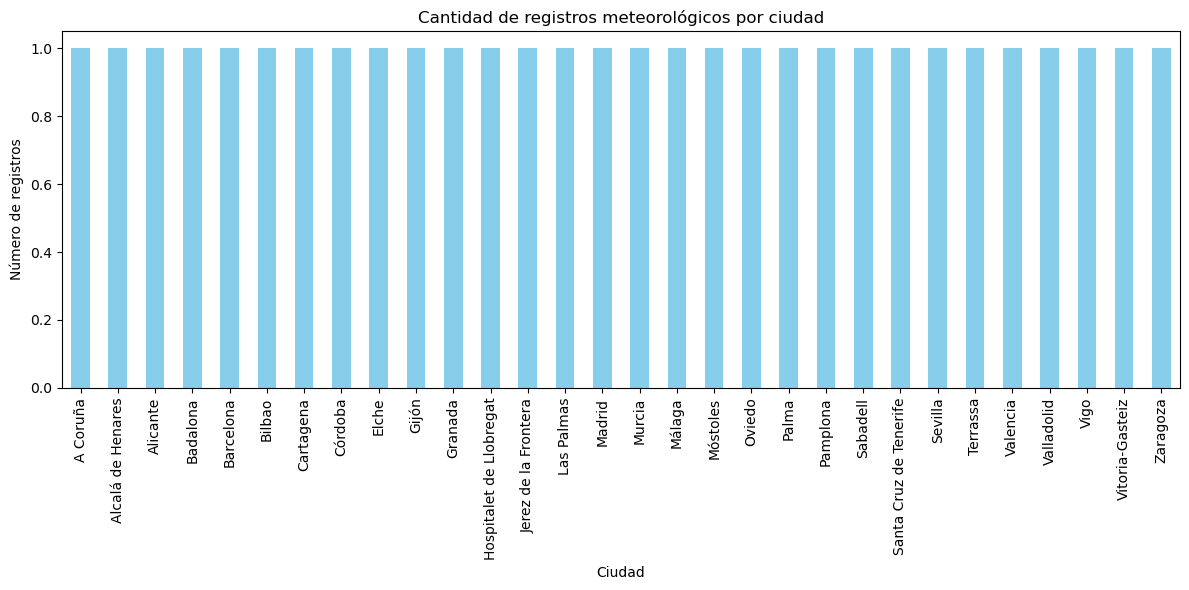

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos de clima 
clima_df = pd.read_csv("datos_tiempo_completos_2025-05-12.csv")

conteo_ciudades = clima_df['ciudad'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
conteo_ciudades.plot(kind='bar', color='skyblue')
plt.xlabel('Ciudad')
plt.ylabel('Número de registros')
plt.title('Cantidad de registros meteorológicos por ciudad')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<h1> Combinación de Datos desde Excel e JSON para Análise Meteorolóxica</h1>

<p> Lo estoy haciendo aqui es cargar los datos meteorológicos desde un archivo CSV ('clima_partidos.csv') y desde un archivo JSON ('datos_tiempo_completos_2025-05-12.json'), y luego mostrando las primeras filas de ambos DataFrames para comparar o revisar los datos cargados. <p>

In [8]:
import pandas as pd

# Cargar datos desde un archivo CSV en lugar del Excel
clima_data = pd.read_csv("clima_partidos.csv")

# Cargar datos desde el archivo JSON existente
json_data = pd.read_json("datos_tiempo_completos_2025-05-12.json")

# Mostrar un resumen de ambos conjuntos de datos
print("Datos desde CSV:")
print(clima_data.head())

print("\nDatos desde JSON:")
print(json_data.head())


Datos desde CSV:
      Cidade        Data  Temperatura  Condición
0     Madrid  2025-04-01         18.0  Despexado
1  Barcelona  2025-04-01         19.0      Nubes
2    Sevilla  2025-04-01         23.0        Sol
3     Bilbao  2025-04-01         15.0     Choiva
4   Valencia  2025-04-01         20.0      Nubes

Datos desde JSON:
      ciudad    tipo       fecha                  timestamp temperatura  \
0     Madrid  actual  2025-05-12 2025-05-12 20:22:59.506912         16°   
1  Barcelona  actual  2025-05-12 2025-05-12 20:23:01.609872         17°   
2   Valencia  actual  2025-05-12 2025-05-12 20:23:04.066366         19°   
3    Sevilla  actual  2025-05-12 2025-05-12 20:23:05.970755         23°   
4   Zaragoza  actual  2025-05-12 2025-05-12 20:23:07.783398         21°   

        condicion  
0  Nubes y claros  
1  Nubes y claros  
2         Soleado  
3         Soleado  
4  Nubes y claros  


<h1> Convertir archivo CSV de clima a formato Excel<h1>

<p> Lo que voy hacer ahora seria leer el archivo de clima_partidos.cvs con pandas y despues guardarlo como un archivo excel llamandolo orixe_datos_clima.xlsx. <p>

In [ ]:
df = pd.read_csv("clima_partidos.csv")
df.to_excel("orixe_datos_clima.xlsx", index=False)


<h1>Carga y limpieza de datos climáticos desde archivo CSV<h1>

<p> Lo que voy a hacer ahora seria cargar el archivo CSV llamado 'datos_tiempo_completos_2025-05-12.csv' en un DataFrame, eliminando las filas con valores nulos y normalizando la columna 'ciudad' (quitando espacios y poniendo en formato título), y luego mostrando el DataFrame limpio.<p>

In [13]:
# Cargar datos de clima desde el archivo CSV generado previamente
clima_df = pd.read_csv("datos_tiempo_completos_2025-05-12.csv")

# Limpiar los datos
clima_df = clima_df.dropna()  # Eliminar filas con valores nulos
clima_df["ciudad"] = clima_df["ciudad"].str.strip().str.title()  # Normalizar nombres de ciudades

# Mostrar el DataFrame limpio
clima_df


,ciudad,tipo,fecha,timestamp,temperatura,condicion
0,A Coruña,actual,2025-12-05,2025-05-12T20:23:38.443770,15°,Nubes y claros
1,Alcalá De Henares,actual,2025-12-05,2025-05-12T20:24:08.143941,17°,Nubes y claros
2,Alicante,actual,2025-12-05,2025-05-12T20:23:23.616426,19°,Nubes y claros
3,Badalona,actual,2025-12-05,2025-05-12T20:23:53.917573,17°,Nubes y claros
4,Barcelona,actual,2025-12-05,2025-05-12T20:23:01.609872,17°,Nubes y claros
5,Bilbao,actual,2025-12-05,2025-05-12T20:23:21.240227,14°,Lluvia débil
6,Cartagena,actual,2025-12-05,2025-05-12T20:23:56.221989,20°,Soleado
7,Córdoba,actual,2025-12-05,2025-05-12T20:23:26.195949,21°,Nubes y claros
8,Elche,actual,2025-12-05,2025-05-12T20:23:45.636329,19°,Nubes y claros
9,Gijón,actual,2025-12-05,2025-05-12T20:23:32.259221,14°,Lluvia débil


<h1> Integración con Spark-HDFS<h1>

<p> Lo que estoy haciendo aqui es crear una SparkSession llamada 'MifutbolData', obteniendo el SparkContext, cargando un archivo CSV desde HDFS ('/user/xuedua088/futbol/partidos_laliga.csv') en un RDD, y mostrando las primeras 5 líneas del RDD con un print compatible con Python 2. <p>

In [ ]:
from pyspark.sql import SparkSession

# Reinitializar SparkSession e SparkContext
spark = SparkSession \
    .builder \
    .appName('MifutbolData') \
    .getOrCreate()
sc = spark.sparkContext

# 2. Cargar os datos nun RDD
# Ruta ao arquivo en HDFS
hdfs_path = 'hdfs:///user/xuedua088/futbol/partidos_laliga.csv'

# Cargar os datos no RDD
rdd = sc.textFile(hdfs_path)

# Visualizar as primeiras liñas
print rdd.take(5)

<p> Ahora voy a cargar el archivo CSV desde HDFS como un RDD, extrayendo y eliminando la cabecera, luego obteniendo solo las columnas de los equipos local y visitante (índices 1 y 2), y finalmente imprimiendo los equipos de cada partido en formato "Local: X - Visitante: Y". <p>

In [ ]:
# Ruta al archivo CSV en HDFS
hdfs_path = 'hdfs:///user/xuedua088/futbol/partidos_laliga.csv'

# Cargar el archivo como un RDD
rdd = sc.textFile(hdfs_path)

# Obtener la cabecera para descartarla después
header = rdd.first()

# Filtrar para eliminar la cabecera
rdd_sin_header = rdd.filter(lambda linea: linea != header)

# Extraer las columnas Local y Visitante (índices 1 y 2)
equipos = rdd_sin_header.map(lambda linea: linea.split(",")[1:3])

# Mostrar los equipos por partido
for local, visitante in equipos.collect():
    print "Local: %s - Visitante: %s" % (local, visitante)

<p> Ahora estoy cargando el archivo CSV desde HDFS como un RDD, eliminando la cabecera, extrayendo las columnas Hora, Local y Visitante (índices 0, 1 y 2), y luego mostrando esa información para cada partido en formato "Hora: X - Local: Y - Visitante: Z". <p>

In [ ]:
# Ruta al archivo CSV en HDFS
hdfs_path = 'hdfs:///user/xuedua088/futbol/partidos_laliga.csv'

# Cargar el archivo como un RDD
rdd = sc.textFile(hdfs_path)

# Obtener la cabecera para descartarla después
header = rdd.first()

# Filtrar para eliminar la cabecera
rdd_sin_header = rdd.filter(lambda linea: linea != header)

# Extraer Hora, Local y Visitante (índices 0, 1 y 2)
partidos = rdd_sin_header.map(lambda linea: linea.split(",")[0:3])

# Mostrar la información por partido
for hora, local, visitante in partidos.collect():
    print "Hora: %s - Local: %s - Visitante: %s" % (hora, local, visitante)

<p> Ahora voy a cerrar correctamente el SparkContext y la SparkSession; si ocurre algún error durante el cierre, se captura la excepción y se muestra un mensaje indicando el problema. <p>

In [ ]:
# Cerrar SparkContext y SparkSession
try:
    sc.stop()
    spark.stop()
    print("Sesión Spark cerrada correctamente.")
except Exception as e:
    print("Error cerrando sesión Spark:", e)

<h3> Capturas del Resultado de las consultas <h3>

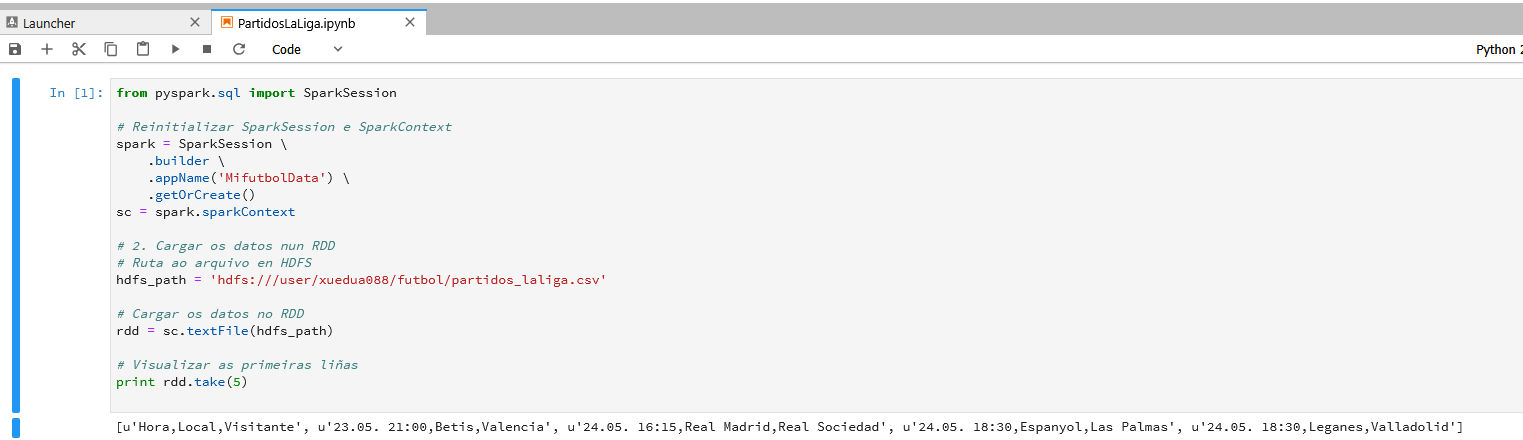

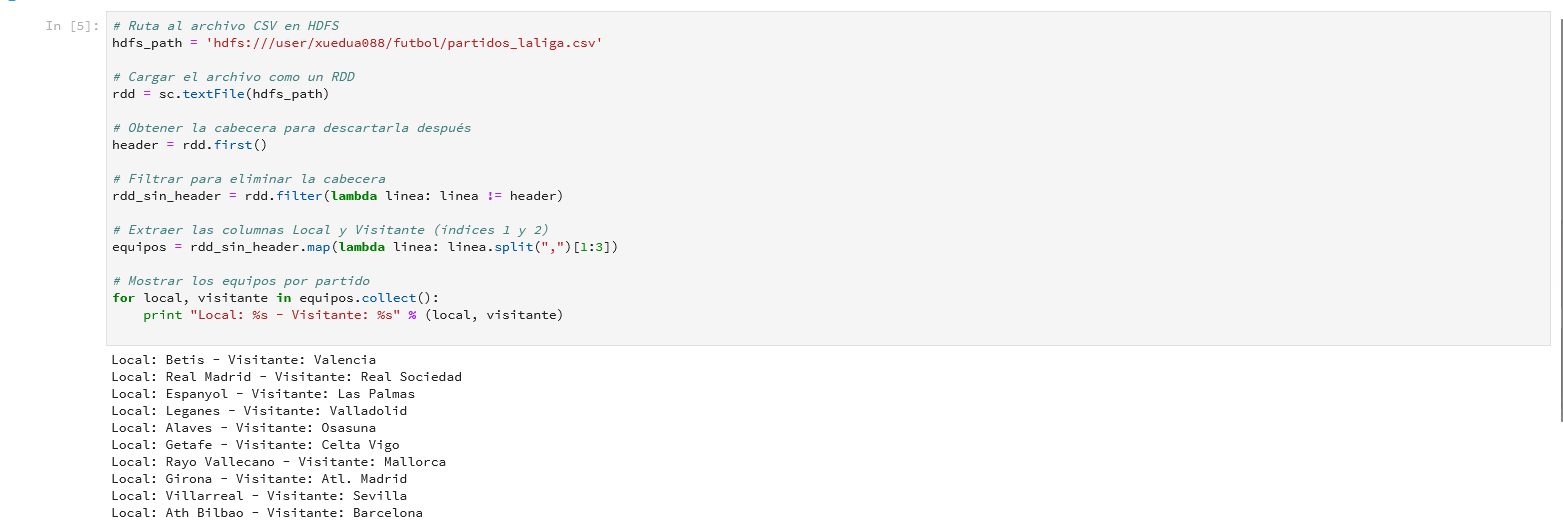

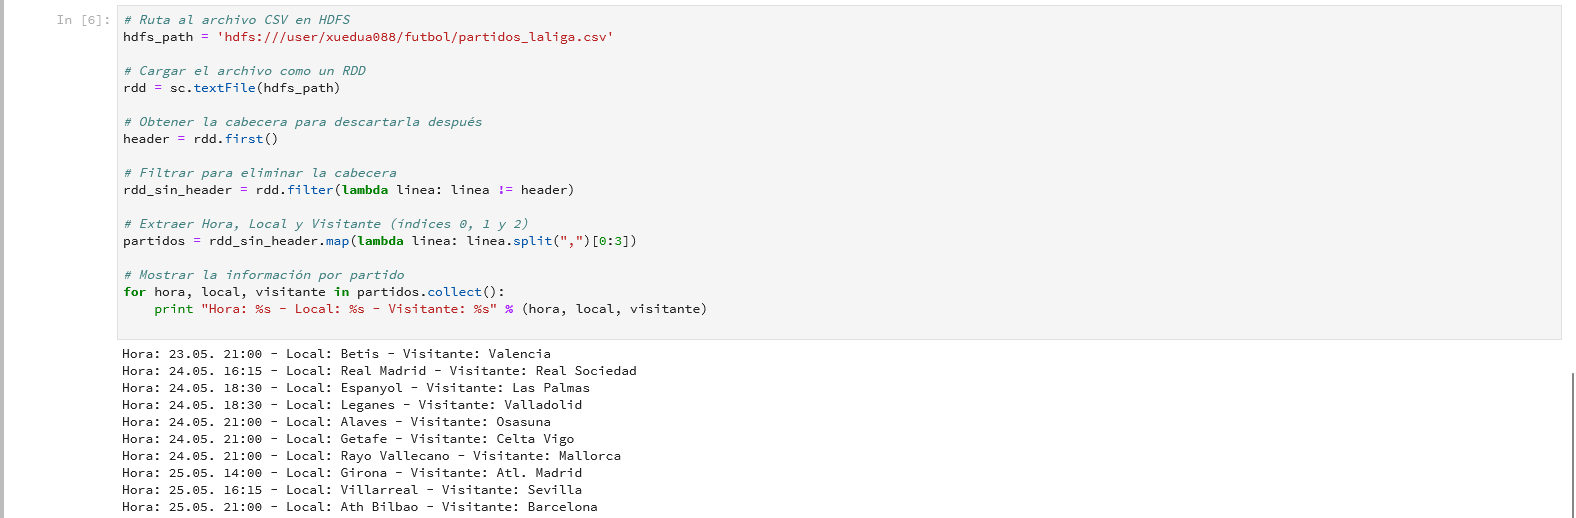

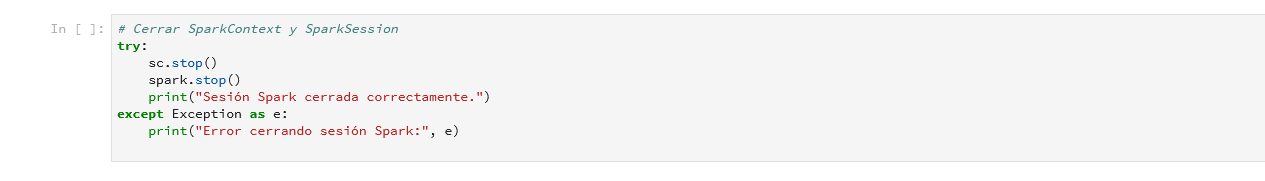

<h1> Cruce de datos de asistencia con condiciones climáticas reales</h1>

<p> Aqui estoy haciendo es cargar los datos de asistencia desde un archivo CSV, combinándolos mediante un inner join con los datos reales de clima filtrados (donde tipo es "actual") según la ciudad, seleccionando columnas relevantes del resultado y mostrando el DataFrame combinado. <p>

In [16]:
# Cargar datos de asistencia desde un archivo CSV
asistencia_df = pd.read_csv("asistencia_estadios.csv")

# Combinar datos reales del clima con los equipos de cada ciudad
datos_combinados = pd.merge(
    asistencia_df,
    clima_df[clima_df["tipo"] == "actual"],  # Filtrar solo datos reales
    left_on="Cidade",
    right_on="ciudad",
    how="inner"
)

# Seleccionar columnas relevantes
datos_combinados = datos_combinados[["Equipo", "Estadio", "Cidade", "temperatura", "condicion", "Asistencia", "Capacidade"]]

# Mostrar los datos combinados
datos_combinados


,Equipo,Estadio,Cidade,temperatura,condicion,Asistencia,Capacidade
0,Real Madrid,Santiago Bernabéu,Madrid,16°,Nubes y claros,70000,81044
1,FC Barcelona,Estadi Olímpic,Barcelona,17°,Nubes y claros,50000,55000
2,Sevilla FC,Ramón Sánchez-Pizjuán,Sevilla,23°,Soleado,35000,43883
3,Athletic Club,San Mamés,Bilbao,14°,Lluvia débil,42000,53289
4,Atlético Madrid,Wanda Metropolitano,Madrid,16°,Nubes y claros,68000,68000
5,Real Betis,Benito Villamarín,Sevilla,23°,Soleado,50000,60000
6,Valencia CF,Mestalla,Valencia,19°,Soleado,46000,55000
7,Granada CF,Nuevo Los Cármenes,Granada,19°,Soleado,22000,22500
8,Celta de Vigo,Abanca-Balaídos,Vigo,14°,Lluvia débil,29000,30000
9,Espanyol,RCDE Stadium,Barcelona,17°,Nubes y claros,29000,40000


<h1> Exportación de datos combinados para uso en Power BI</h1>

<p> Aqui estoy guardando el DataFrame combinado en un archivo CSV llamado 'datos_combinados_powerbi.csv', sin incluir el índice y usando codificación UTF-8 con BOM para compatibilidad, y luego imprimiendo un mensaje de confirmación. <p>

In [ ]:
# Guardar el DataFrame combinado en un archivo CSV
datos_combinados.to_csv("datos_combinados_powerbi.csv", index=False, encoding="utf-8-sig")

print(" Archivo 'datos_combinados_powerbi.csv' guardado exitosamente.")

<h1> Xeración de datos meteorolóxicos simulados para análise<h1>

<p> Aqui estoy generando datos meteorológicos simulados para 8 ciudades durante 7 días (temperatura y condición del tiempo aleatoria) porque no fui capaz de sacarlos desde la pagina y por eso los simulo yo, y por eso voy a crear un DataFrame con esos datos y guardándolo en un archivo CSV llamado 'datos_meteoroloxicos_simulados.csv' con codificación UTF-8 con BOM. <p>

In [ ]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Lista de cidades
cidades = ["Madrid", "Barcelona", "Sevilla", "Bilbao", "Valencia", "Vigo", "Granada", "San Sebastián"]

# Condicións meteorolóxicas posibles
condicions = ["Despexado", "Nubes", "Sol", "Choiva"]

# Xerar datos simulados
datos = []
data_inicial = datetime(2025, 4, 1)
for cidade in cidades:
    for i in range(7):  # Datos para 7 días
        data = data_inicial + timedelta(days=i)
        temperatura = round(random.uniform(10, 25), 1)  # Temperatura entre 10 e 25 graos
        condicion = random.choice(condicions)
        datos.append({"Cidade": cidade, "Data": data.strftime("%Y-%m-%d"), "Temperatura": temperatura, "Condición": condicion})

# Crear un DataFrame
df = pd.DataFrame(datos)

# Gardar os datos nun arquivo CSV
arquivo_csv = "datos_meteoroloxicos_simulados.csv"
df.to_csv(arquivo_csv, index=False, encoding="utf-8-sig")

print(f" Datos meteorolóxicos simulados gardados en '{arquivo_csv}'")

✅ Datos meteorolóxicos simulados gardados en 'datos_meteoroloxicos_simulados.csv'


<h1> Gráficas en Power BI</h1>

<h3>Página 1 de Informes<h3>

**" Análisis de Temperatura Media por Ciudad"**

<p> Aqui estoy carganndo el archivo CSV con datos combinados, limpiando la columna 'temperatura' para convertirla a números (eliminando el símbolo °), agrupando por ciudad para calcular la temperatura media, y luego generando un gráfico de línea que muestra la temperatura media por ciudad con etiquetas y formato adecuado. <p>

In [ ]:
##Graficar la temperatura media por ciudad
# Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt

# Cargar los datos
clima_df = pd.read_csv('C:/Users/constantin.madalin.i/Tareas-y-Ejercicios-de-Clase2/Tareas-y-Ejercicios-de-Clase/SBD/Clase de Profesor Victor/Proyecto Futbol/datos_combinados_powerbi.csv')

# Limpiar temperatura
clima_df['temperatura'] = clima_df['temperatura'].str.replace('°', '', regex=False).astype(float)

# Agrupar por ciudad y calcular temperatura media (puedes cambiar a mediana si prefieres)
media_temp = clima_df.groupby('Cidade')['temperatura'].mean().sort_values()

# Crear gráfico de línea
plt.figure(figsize=(10, 6))
plt.plot(media_temp.index, media_temp.values, marker='o', linestyle='-', color='b')

# Estética
plt.xticks(rotation=90)
plt.ylabel("Temperatura media (°C)")
plt.title("Temperatura media por cidade")
plt.grid(True)
plt.tight_layout()
plt.show()
plt.show()


**" Comparación de Asistencia y Capacidad por Equipo en Estadios de Fútbol"**

<p> En esta estoy cargando los datos combinados de asistencia y capacidad por equipo y ciudad, convirtiendo las columnas a valores numéricos, agrupando por equipo y ciudad para calcular los promedios de asistencia y capacidad, y luego creando un gráfico de barras comparativo que muestra la capacidad y asistencia promedio por equipo. <p>

In [ ]:
##Gráfico de barras comparando Asistencia y Capacidad por Equipo
# Importar librerías necesarias

import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('C:/Users/constantin.madalin.i/Tareas-y-Ejercicios-de-Clase2/Tareas-y-Ejercicios-de-Clase/SBD/Clase de Profesor Victor/Proyecto Futbol/datos_combinados_powerbi.csv')

# Convertir columnas a numéricas
df['asistencia'] = pd.to_numeric(df['Asistencia'], errors='coerce')
df['capacidade'] = pd.to_numeric(df['Capacidade'], errors='coerce')

# Agrupar por Equipo y Cidade
agrupado = df.groupby(['Equipo', 'Cidade'], as_index=False).agg({
    'asistencia': 'mean',
    'capacidade': 'mean'
})

# Crear gráfico de barras comparativo
plt.figure(figsize=(14, 6))
x = range(len(agrupado))
plt.bar(x, agrupado['capacidade'], width=0.4, label='Capacidade', align='center')
plt.bar([i + 0.4 for i in x], agrupado['asistencia'], width=0.4, label='Asistencia', align='center')

# Etiquetas
plt.xticks([i + 0.2 for i in x], agrupado['Equipo'], rotation=90)
plt.ylabel("Número de personas")
plt.title("Asistencia vs Capacidad por Equipo")
plt.legend()
plt.tight_layout()
plt.show()


<h3>Página 2 de Informes<h3>

**" Comparación de Asistencia y Capacidad por Ciudad y Estadio"**

<p> En esta grafica estoy cargando datos de asistencia y capacidad de estadios (si no están ya cargados), convirtiendo las columnas relevantes a números, agrupando por ciudad y estadio para calcular los promedios, y creando un gráfico de barras comparativo que muestra la capacidad y asistencia promedio por ciudad y estadio. <p>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos si no está definido
if 'df' not in locals():
    df = pd.read_csv('C:/Users/constantin.madalin.i/Tareas-y-Ejercicios-de-Clase2/Tareas-y-Ejercicios-de-Clase/SBD/Clase de Profesor Victor/Proyecto Futbol/asistencia_estadios.csv')

# Convertir columnas a numéricas
df['asistencia'] = pd.to_numeric(df['Asistencia'], errors='coerce')
df['capacidade'] = pd.to_numeric(df['Capacidade'], errors='coerce')

# Agrupar por Cidade y Estadio
agrupado = df.groupby(['Cidade', 'Estadio'], as_index=False).agg({
    'asistencia': 'mean',
    'capacidade': 'mean'
})

# Crear gráfico de barras comparativo
plt.figure(figsize=(14, 6))
x = range(len(agrupado))
plt.bar(x, agrupado['capacidade'], width=0.4, label='Capacidade', align='center')
plt.bar([i + 0.4 for i in x], agrupado['asistencia'], width=0.4, label='Asistencia', align='center')

# Etiquetas
plt.xticks([i + 0.2 for i in x], agrupado['Cidade'] + " - " + agrupado['Estadio'], rotation=90)
plt.ylabel("Número de personas")
plt.title("Asistencia vs Capacidad por Cidade y Estadio")
plt.legend()
plt.tight_layout()
plt.show()

<h1> Referencias de Páginas </h1>


Página del tiempo: https://www.tiempo.com

Página del Futbol: https://www.flashscore.com/football/spain/laliga/